# QR Decomposition

**Source:** https://labs.acme.byu.edu/Volume1/QR_Decomposition/QR_Decomposition.html

The QR decomposition factors a matrix A into an orthogonal matrix Q and an upper triangular matrix R. This lab implements two algorithms: Modified Gram-Schmidt orthogonalization and Householder triangularization.

In [1]:

import numpy as np
from scipy import linalg as la

## 1. Classical vs Modified Gram-Schmidt

Given a matrix A with linearly independent columns, Gram-Schmidt produces an orthonormal basis Q and upper triangular R such that A = QR.

**Classical GS** suffers from numerical instability. **Modified GS** reorthogonalizes at each step, giving much better numerical properties.

In [2]:
def gram_schmidt(A):
    """Classical Gram-Schmidt QR factorization (numerically unstable)."""
    m, n = A.shape
    Q = np.zeros((m, n))
    R = np.zeros((n, n))
    for j in range(n):
        v = A[:, j].copy().astype(float)
        for i in range(j):
            R[i, j] = Q[:, i] @ A[:, j]
            v -= R[i, j] * Q[:, i]
            
        R[j, j] = np.linalg.norm(v)
        Q[:, j] = v / R[j, j]
    return Q, R

A = np.random.randint(1, 10, (5, 3)).astype(float)
Q, R = gram_schmidt(A)
print("A = QR?  Max error:", np.max(np.abs(A - Q @ R)))
print("Q^T Q = I? Max error:", np.max(np.abs(Q.T @ Q - np.eye(3))))

A = QR?  Max error: 8.881784197001252e-16
Q^T Q = I? Max error: 2.220446049250313e-16


## 2. Householder Triangularization

Householder reflectors $H = I - 2\mathbf{v}\mathbf{v}^T$ eliminate subdiagonal entries column by column. This produces a numerically stable QR factorization even for ill-conditioned matrices.

Key: choose the sign of $v_1$ opposite to the sign of $x_1$ to avoid cancellation:
$$\mathbf{v} = \mathbf{x} + \text{sign}(x_1)\|\mathbf{x}\|\mathbf{e}_1$$

---

## Problem 1: Modified Gram-Schmidt

Implement the modified Gram-Schmidt algorithm. Returns orthonormal Q (m×n) and upper triangular R (n×n).

In [3]:
def prob1(A):
    """Modified Gram-Schmidt QR factorization.
    
    Parameters
    ----------
    A : ndarray of shape (m, n) with linearly independent columns
    
    Returns
    -------
    Q : ndarray (m, n) — orthonormal columns
    
    R : ndarray (n, n) — upper triangular
    """
    m, n = A.shape
    Q = A.copy().astype(float)
    R = np.zeros((n, n))
    for i in range(n):
        R[i, i] = np.linalg.norm(Q[:, i])
        Q[:, i] /= R[i, i]
        for j in range(i + 1, n):
            R[i, j] = Q[:, i] @ Q[:, j]
            Q[:, j] -= R[i, j] * Q[:, i]
    return Q, R


# Verify
A = np.random.randint(1, 10, (6, 4)).astype(float)
Q, R = prob1(A)
print("A = QR?  Max error:", np.max(np.abs(A - Q @ R)))
print("Q^T Q = I? Max error:", np.max(np.abs(Q.T @ Q - np.eye(4))))
print("R upper triangular? (lower should be ~0):", np.allclose(np.tril(R, -1), 0))

A = QR?  Max error: 8.881784197001252e-16
Q^T Q = I? Max error: 2.97262087240956e-16
R upper triangular? (lower should be ~0): True


## Problem 2: Householder QR

Implement Householder triangularization. Returns the full orthogonal Q (m×m) and upper triangular R (m×n).

In [4]:
def prob2(A):
    """Householder triangularization. Returns Q (m×m) and R (m×n)."""
    m, n = A.shape
    R = A.copy().astype(float)
    Q = np.eye(m)
    for k in range(n):
        u = R[k:, k].copy()
        u[0] += np.sign(u[0]) * np.linalg.norm(u)
        u /= np.linalg.norm(u)
        R[k:, k:] -= 2 * np.outer(u, u @ R[k:, k:])
        
        Q[k:, :] -= 2 * np.outer(u, u @ Q[k:, :])
    return Q.T, R


A = np.random.randint(1, 10, (5, 3)).astype(float)
Q, R = prob2(A)
print("A = QR?  Max error:", np.max(np.abs(A - Q[:, :3] @ R[:3, :])))
print("Q^T Q = I? Max error:", np.max(np.abs(Q.T @ Q - np.eye(5))))
print("R upper triangular?:", np.allclose(np.tril(R, -1), 0))

A = QR?  Max error: 3.9968028886505635e-15
Q^T Q = I? Max error: 1.1102230246251565e-15
R upper triangular?: True


## Problem 3: Householder with Implicit Q

Store Householder vectors instead of building Q explicitly. Apply them to a vector b efficiently.

In [5]:
def prob3(A):
    """Householder triangularization storing reflector vectors.
    
    Returns
    -------
    R    : ndarray (m, n) — upper triangular
    vecs : list of n unit vectors defining each reflector
    """
    m, n = A.shape
    R = A.copy().astype(float)
    vecs = []
    for k in range(n):
        
        u = R[k:, k].copy()
        u[0] += np.sign(u[0]) * np.linalg.norm(u)
        u /= np.linalg.norm(u)
        vecs.append(u)
        R[k:, k:] -= 2 * np.outer(u, u @ R[k:, k:])
    return R, vecs


def apply_Qtb(vecs, b):
    """Apply Q^T to vector b using stored Householder vectors."""
    x = b.copy().astype(float)
    for k, u in enumerate(vecs):
        x[k:] -= 2 * u * (u @ x[k:])
    return x


A = np.random.randint(1, 10, (6, 4)).astype(float)
b = np.random.randn(6)
R, vecs = prob3(A)
Qtb = apply_Qtb(vecs, b)

# Compare with scipy
Q_ref, R_ref = la.qr(A)
print("Q^T b matches scipy?:", np.allclose(Qtb[:4], (Q_ref.T @ b)[:4]))

Q^T b matches scipy?: True


## Problem 4: Solve Ax=b with QR

Use the QR decomposition to solve a square system: compute Q^T b, then back-substitute with R.

In [6]:
def prob4(A, b):
    """Solve Ax = b using the QR decomposition.
    
    Parameters
    ----------
    A : square ndarray (n, n)
    b : ndarray (n,)
    
    Returns
    -------
    x : ndarray (n,) — solution
    """
    Q, R = prob1(A)
    y = Q.T @ b
    
    # Back-substitution
    n = len(b)
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (y[i] - R[i, i+1:] @ x[i+1:]) / R[i, i]
    return x


n = 5
A = np.random.randint(1, 10, (n, n)).astype(float)
b = np.random.randn(n)
x = prob4(A, b)
print("Ax - b (should be ~0):", np.max(np.abs(A @ x - b)))
print("Matches np.linalg.solve?:", np.allclose(x, np.linalg.solve(A, b)))

Ax - b (should be ~0): 2.1371793224034263e-15
Matches np.linalg.solve?: True


## Problem 5: QR Decomposition Timing

Compare the time complexity of Modified Gram-Schmidt vs scipy's QR (LAPACK Householder) as matrix size grows.

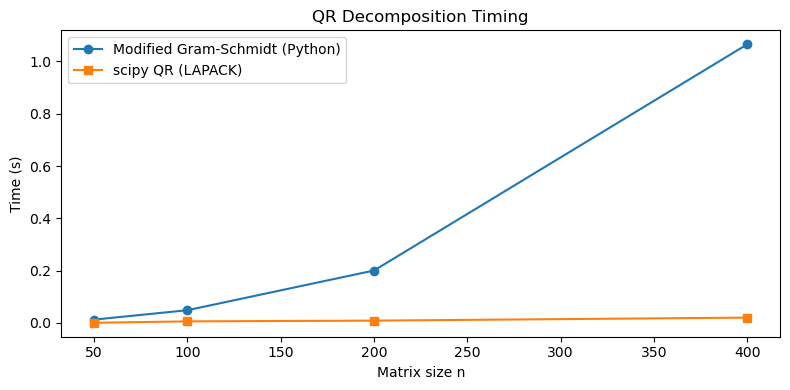

In [7]:
import time
import matplotlib.pyplot as plt

sizes = [50, 100, 200, 400]
times_mgs  = []
times_lapack = []


for n in sizes:
    A = np.random.randn(n, n)
    
    t0 = time.time()
    prob1(A)
    times_mgs.append(time.time() - t0)
    
    t0 = time.time()
    la.qr(A)
    times_lapack.append(time.time() - t0)

plt.figure(figsize=(8, 4))
plt.plot(sizes, times_mgs,   'o-', label='Modified Gram-Schmidt (Python)')
plt.plot(sizes, times_lapack, 's-', label='scipy QR (LAPACK)')
plt.xlabel('Matrix size n')
plt.ylabel('Time (s)')
plt.title('QR Decomposition Timing')
plt.legend()
plt.tight_layout()
plt.show()

## Problem 6: Least Squares via QR

Use the thin QR factorization to solve the least squares problem $\min_x \|Ax - b\|_2$ for overdetermined systems.

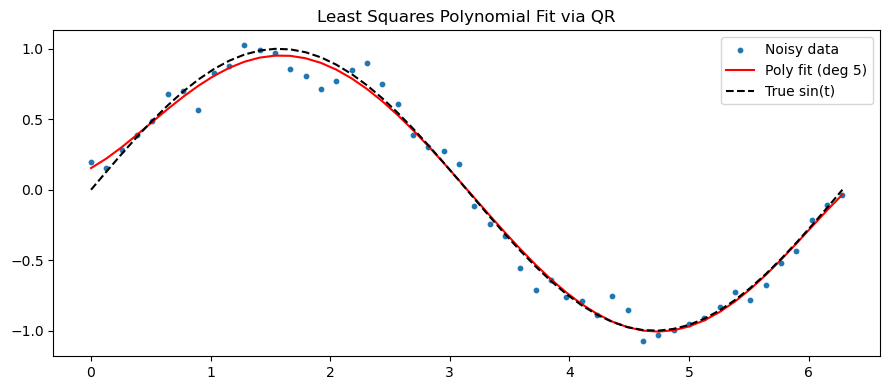

Max diff from numpy lstsq: 1.5697443345175088e-12


In [8]:
def prob6(A, b):
    """Least squares solution to Ax ≈ b using thin QR (A is m×n, m > n)."""
    Q, R = prob1(A)  # Q is m×n, R is n×n
    y = Q.T @ b      # n×1
    # Back-substitution with R
    n = R.shape[0]
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (y[i] - R[i, i+1:] @ x[i+1:]) / R[i, i]
    return x


# Fit a degree-3 polynomial to noisy data
t = np.linspace(0, 2*np.pi, 50)
y_true = np.sin(t)
y_noisy = y_true + 0.1 * np.random.randn(50)


# Vandermonde-style design matrix for degree 5
degree = 5
A = np.vstack([t**k for k in range(degree + 1)]).T
coeffs = prob6(A, y_noisy)

plt.figure(figsize=(9, 4))
plt.scatter(t, y_noisy, s=10, label='Noisy data')
plt.plot(t, A @ coeffs, 'r-', label=f'Poly fit (deg {degree})')
plt.plot(t, y_true, 'k--', label='True sin(t)')
plt.legend()
plt.title('Least Squares Polynomial Fit via QR')
plt.tight_layout()
plt.show()

# Compare residuals with numpy lstsq
x_ref = np.linalg.lstsq(A, y_noisy, rcond=None)[0]
print("Max diff from numpy lstsq:", np.max(np.abs(coeffs - x_ref)))